# Segmentation des clients olist : modélisation

### Table des matières

* [**1. Introduction**](#chapter1)
* [**2. Chargement**](#chapter2)
* [**3. Fonctions pour le clustering**](#chapter3)
* [**4. Clustering rfm**](#chapter4)
    * [4.1. KMeans](#section_4_1)
    * [4.2. DBScan](#section_4_2)
* [**5. Clustering rfm2**](#chapter5)
    * [5.1. KMeans](#section_5_1)
    * [5.2. DBScan](#section_5_2)
* [**6. Visualisation TSNE**](#chapter6)
* [**7. Maintenance**](#chapter7)
* [**8. Conclusion**](#chapter8)


## 1 - Introduction <a class="anchor" id="chapter1"></a>


A partir des deux jeux de données créés lors de l'analyse exploratoire, une modélisation est effectuée dans ce document afin de créer de segmenter les clients pour des campagnes de communication.  

Deux fichiers sont utilisés en entrée :  

RFM1 : fichier contenant les caractéristiques (par client):  
- Recency  
- Frequency  
- Monetary values  

RFM2 : fichier contenant en plus des caractériqtiques de RFM1 (par client): 
- le review score moyen
- le délai de livraison moyen
- l'heure d'achat moyenne


## 2 - Chargement <a class="anchor" id="chapter2"></a>


In [358]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn')

In [359]:
data_path = "./datas/"
rfm1 = pd.read_csv(data_path + "rfm1.csv", low_memory=False)
rfm2 = pd.read_csv(data_path + "rfm2.csv", low_memory=False)
rfm1 = rfm1.set_index('customer_unique_id')
rfm2 = rfm2.set_index('customer_unique_id')

## 3 - Définition des fonctions pour le clustering <a class="anchor" id="chapter3"></a>


In [360]:

# KMeans functions

from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
import math

clusters_range = [3, 4, 5, 6, 7]
km_metric = 'euclidean'


def kmeans_parameters(n_clusters):
    """create kmeans parameters dict with predefined values

        Parameters:
        n_clusters (int): the number of clusters

        Returns:
        km_parameters: the kmeans parameters

    """    
    km_parameters = {
        'n_clusters' : n_clusters,
        'init' : 'k-means++',
        'random_state' : 42}
    return km_parameters


def silhouette_analysis(ds):
    """calculate silhouette score and plot silhouette (SilhouetteVisualizer)
       for each values of predifined clusters_range for kmeans n_clusters parameter

        Parameters:
        ds (dataframe): the dataset to analyze

        Returns:
        silhouette_scores: the silhouettes scores dict for predifined clusters_range 
        pipelines: pipelines fit for predifined clusters_range 

    """    
    
    silhouette_scores={}
    pipelines={}
    plt.figure(figsize=(15,math.ceil(len(clusters_range)/2)*7))
    
    for i in clusters_range:

        # fit clusterer (kmeans) for clusters_range values and get labels results
        pipeline = define_pipeline(preprocessor, KMeans(**kmeans_parameters(i))) # define pipeline with model choosed
        preprocessed_data = pipeline["preprocessor"].fit_transform(ds) # normalize datas
        pipeline["clusterer"].fit(preprocessed_data)
        predicted_labels = pipeline["clusterer"].labels_
        pipelines[i] = pipeline

        # calculate silhouette score with current predicted labels
        silhouette_score = metrics.silhouette_score(preprocessed_data, predicted_labels, metric=km_metric)
        silhouette_scores[i]=silhouette_score

        ax = plt.subplot(math.ceil(len(clusters_range)/2),2,i - min(clusters_range)+1)

        # fit silhouette visualizer with clusterer(kmeans)
        visualizer = SilhouetteVisualizer(pipeline["clusterer"], colors='yellowbrick')
        visualizer.fit(preprocessed_data)     

        title = str(i) + ' clusters - '+ ' silhouette score : ' + str(silhouette_score)
        plt.title(title, size=15)    
        
    return silhouette_scores, pipelines



In [361]:

# pipeline functions

def df_pipe_results(ds, pipeline):
    """create a dataframe with pipeline clusterer labels 

        Parameters:
        ds (dataframe): the dataset to treat
        pipeline (pipeline): the pipeline with preprocessor and clusterer to use

        Returns:
        df_results: dataframe containing datas preprocessed and labels clusters

    """    
    preprocessed_data = pipeline["preprocessor"].transform(ds) # normalize
    predicted_labels = pipeline["clusterer"].labels_ # get labels
    df_results = pd.DataFrame(preprocessed_data,columns=ds.columns) # create dataframe with normalize datas
    df_results['label']= predicted_labels # add labels to result dataframe
    return df_results

def define_pipeline(preprocessor, clusterer):
    """create a pipeline with the preprocessor and clusterer parameters

        Parameters:
        preprocessor : the preprocessor (eg. StandardScaler)
        pipeline (pipeline): the clusterer (eg. KMeans) 

        Returns:
        pipeline: the created pipeline

    """    
    preprocessor_pipe = Pipeline([("scaler",StandardScaler())])
    pipeline = Pipeline([("preprocessor", preprocessor_pipe),("clusterer",clusterer)])
    return pipeline


In [362]:

# DBScan functions


from sklearn.cluster import DBSCAN

range_eps=[0.2,0.4,0.6,0.8,1,2,3,4,5,6,7,8,9,10]
range_min_samples=[1,5,10]


def dbscan_parameters(eps,min_samples):
    """create dbscan parameters dict with parameters values

        Parameters:
        eps (int): the dbscan epsilon parameter
        min_samples (int): the dbscan min_samples parameter

        Returns:
        dbs_parameters: the dbscan parameters

    """    
    dbs_parameters = {
        'eps' : eps,
        'min_samples' : min_samples}
    return dbs_parameters


def dbscan_tuning(ds):
    """use pipeline with preprocessor and dbscan on dataset 
       for range_min_sample and range_eps values
       to find clusters and calculate silhouette scores

        Parameters:
        ds (dataframe): the dataset on which find clusters

        Returns:
        dbscan_silhouette_scores: the silhouette scores for each parmeters
        dbscan_nb_clusters : the clusters number for each parameters
        pipelines : pipelines fit for each parameters

    """    

    dbscan_silhouette_scores={}
    dbscan_nb_clusters={}
    dbscan_pipelines={}

    for min_samples in range_min_samples:
        silhouette_scores={}
        nb_clusters={}
        pipelines={}
        for eps in range_eps:
            
            # fit dbscan on preprocessed datas, get labels results nad calculate silhouette_score
            pipeline = define_pipeline(preprocessor, DBSCAN(**dbscan_parameters(eps,min_samples))) # define pipeline with model choosed
            preprocessed_datas = pipeline["preprocessor"].fit_transform(ds) # normalize datas
            dbs = pipeline['clusterer'].fit(preprocessed_datas)
            labels = dbs.labels_
            
            if len(np.unique(dbs.labels_))>1:
                silhouette_scores[eps]=metrics.silhouette_score(preprocessed_datas, labels)
            else:
                silhouette_scores[eps] = 1
                
            nb_clusters[eps] = len(np.unique(dbs.labels_))
            pipelines[eps] = pipeline
            
        dbscan_silhouette_scores[min_samples] = silhouette_scores
        dbscan_nb_clusters[min_samples] = nb_clusters
        dbscan_pipelines[min_samples] = pipelines
        
    return dbscan_silhouette_scores,dbscan_nb_clusters,dbscan_pipelines


def plot_dbscan_tuning(dbscan_silhouette_scores,dbscan_nb_clusters):
    """plot silhouette scores and number of clusters from parameters values

        Parameters:
        dbscan_silhouette_scores (dict): the silhouette scores
        dbscan_nb_clusters (dict): the numbers of clusters

    """    

    index=0
    fig = plt.figure(figsize=(15,12))

    for min_samples in range_min_samples:

        index+=1

        # get silhouette scores 
        list_scores = sorted(dbscan_silhouette_scores[min_samples].items())
        x_scores, y_scores = zip(*list_scores)
        
        # get clusters numbers 
        list_clusters = sorted(dbscan_nb_clusters[min_samples].items())
        x_clusters, y_clusters = zip(*list_clusters)

        # plot silhouette scores and clusters numbers
        
        ax1 = plt.subplot(2,2,index)

        ax1.plot(x_scores,y_scores,label='silhouette score')
        ax2 = ax1.twinx()
        ax2.plot(x_clusters, y_clusters, color='r',label='clusters number')

        ax1.set_xlabel('epsilon')
        ax1.set_ylabel('silhouette score')
        ax2.set_ylabel('clusters number')

        legend = ax1.legend(loc='center right')
        legend = ax2.legend(loc='center')
        legend.get_frame().set_facecolor('C0')

        ax1.set_title('epsilon dbscan tuning (min_samples:' + str(min_samples) + ')')



In [363]:
# radar chart functions

def radar_chart(df_results):
    """get stats from a clustering dataframe results
       and plot radar charts from these stats

        Parameters:
        df_results (dataframe): the dataframe to treat

    """    
    stats = stats_for_radar_chart(df_results)
    plot_radar_charts(stats)

    
def make_radar_chart( stats_index, index, color,df):
    """make a radar chart for a cluster from the stats of clustering dataframe results and plot it

        Parameters:
        df (dataframe): the dataframe containing stats of clustering results
        index (int): the cluster label number
        stats_index (int): the index in df of the cluster
        color: the color of the cluster

    """    
    
    # number of variable
    categories=list(df)[:-1]
    N = len(categories)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Initialise the spider plot
    ax = plt.subplot(math.ceil(len(df)/2),2,index+1, polar=True, )

    # Draw one axe per variable + add labels labels yet
    plt.xticks(angles[:-1], categories, color='grey', size=8)

    # Draw ylabels
    ax.set_rlabel_position(0)
    min_val = int(df.drop(columns=['label']).min().min())-1
    max_val = int(df.drop(columns=['label']).max().max())+1
    pas = math.ceil((max_val-min_val)/10)
    plt.yticks(range(min_val,max_val,pas), range(min_val,max_val,pas), color="grey", size=7)
    plt.ylim(min_val,max_val)
    
    # Ind1
    values=df.loc[stats_index].drop('label').values.flatten().tolist()
    values += values[:1]
   
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.4)
    
    # Add a title
    
    title = 'cluster '+ str(index) + ' (' + str(int(df.loc[stats_index]['label'])) + ' clients' + ')'
    plt.title(title, size=15, color=color, y=1.1)    

    
def plot_radar_charts(stats):
    """calculate the mean of columns values of df_results
       and the number number of values for each label cluster

        Parameters:
        df_results (dataframe): the dataframe containing clustering results

        Returns:
        stats: the dataframe containing stats calculated

    """    
    size = math.ceil(len(stats)/2)*7
    plt.figure(figsize=(15,size))
    plt.gcf().subplots_adjust(hspace = 0.3)
    my_palette = plt.cm.get_cmap("Set2", len(stats.index))
    index = 0
    for stats_index in stats.index:
        make_radar_chart( stats_index=stats_index, index = index, color=my_palette(index),df=stats)
        index +=1

        
def stats_for_radar_chart(df_results):
    """calculate the mean of columns values of df_results
       and the number number of values for each label cluster

        Parameters:
        df_results (dataframe): the dataframe containing clustering results

        Returns:
        stats: the dataframe containing stats calculated

    """    
    agg_funcs={}
    for col in df_results.columns:
        if col != 'label':
            agg_funcs[col] = 'mean'
        else:
            agg_funcs[col]= lambda x: len(x)
    stats = df_results.groupby('label').agg(agg_funcs)
    return stats        

## 4 - Clustering RFM <a class="anchor" id="chapter4"></a>

In [392]:
preprocessor = StandardScaler()

In [393]:
sample_size = 10000
ds_sample_rfm1 = rfm1.sample(sample_size)


### 4.1 - KMeans <a class="anchor" id="section_4_1"></a>

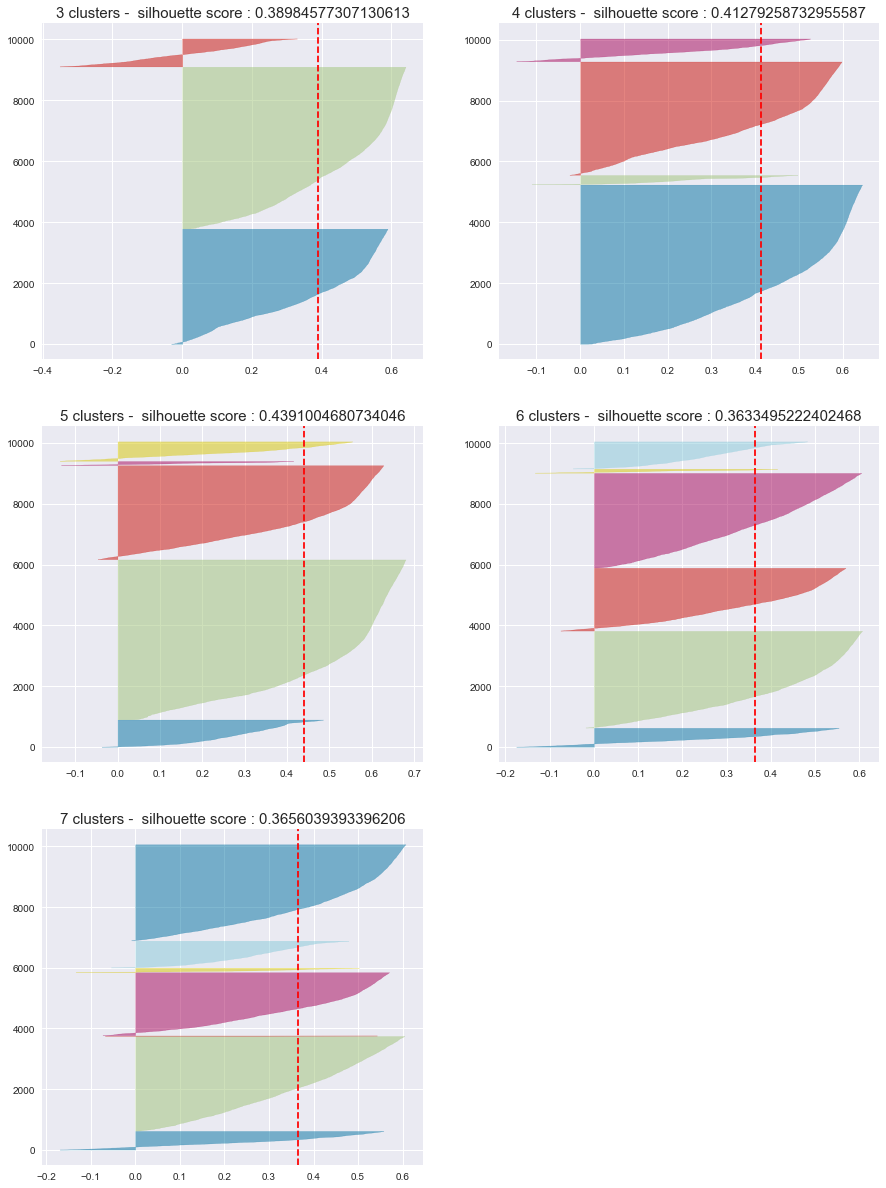

In [394]:
silhouette_scores,pipelines_rfm1_km = silhouette_analysis(ds_sample_rfm1)


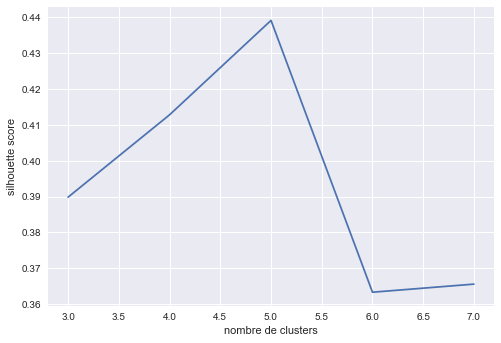

In [395]:
ax = sns.lineplot(data=silhouette_scores)
ax.set_xlabel('nombre de clusters')
ax.set_ylabel('silhouette score')
plt.show()

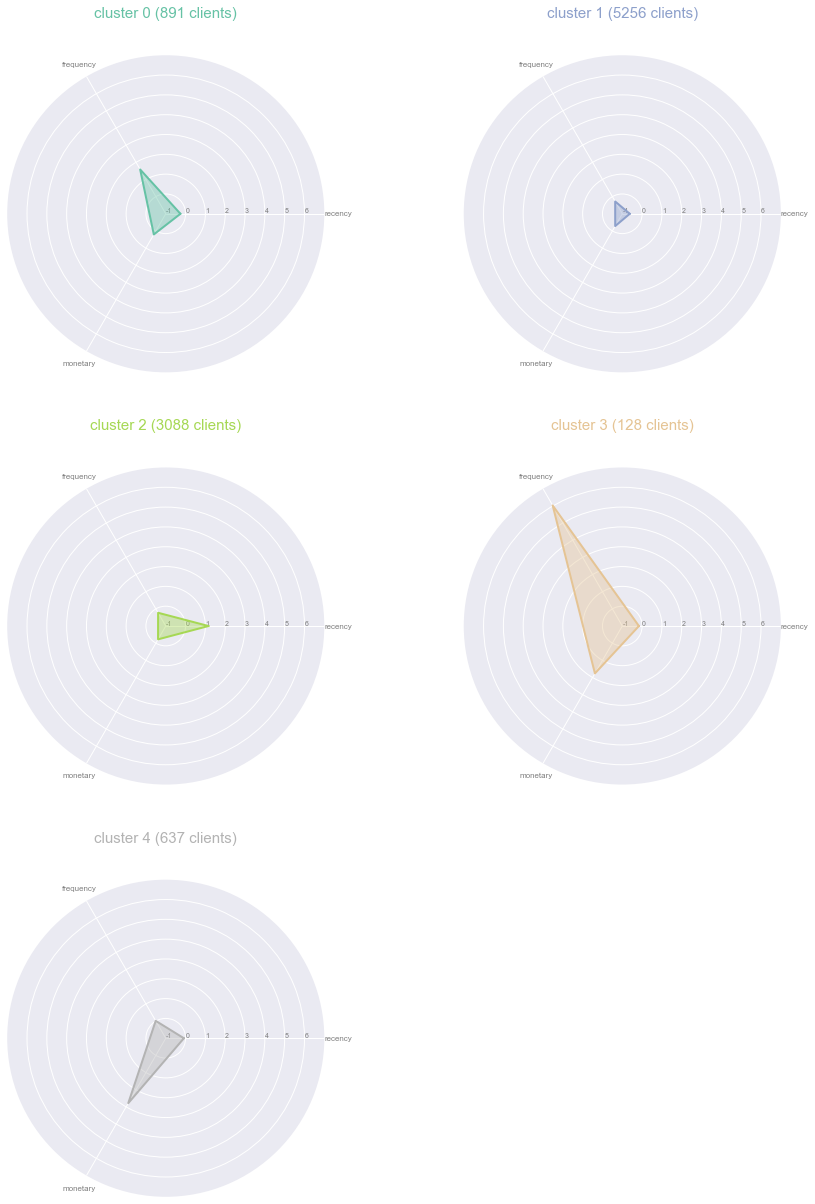

In [396]:

k = 5
pipeline = pipelines_rfm1_km[k]
df_results = df_pipe_results(ds_sample_rfm1, pipeline)
radar_chart(df_results)


### 4.2 - DBScan <a class="anchor" id="section_4_2"></a>

In [369]:
dbscan_silhouette_scores,dbscan_nb_clusters,dbscan_pipelines = dbscan_tuning(ds_sample_rfm1)

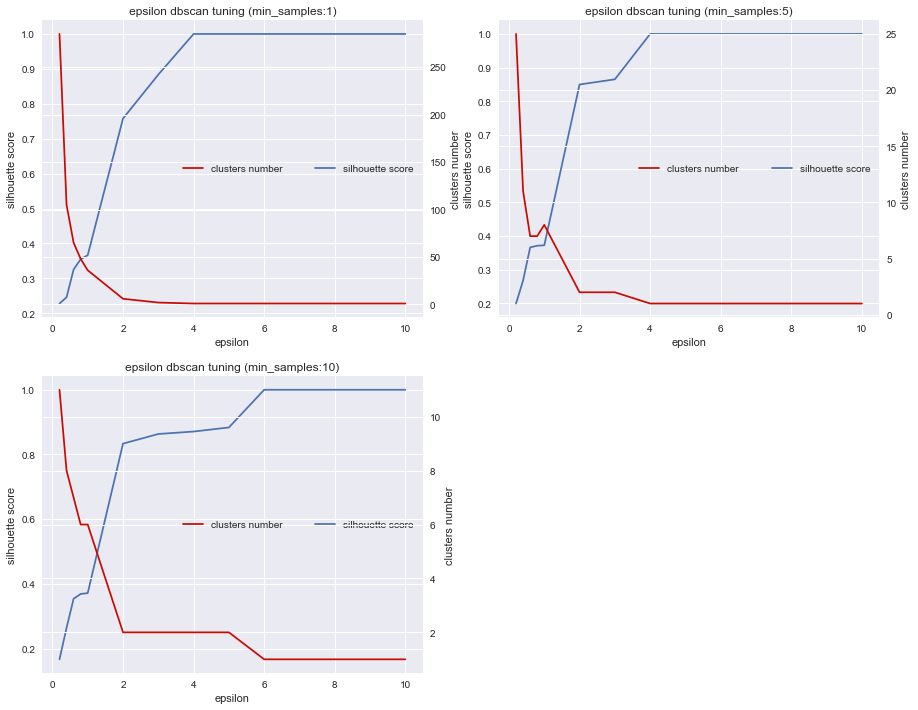

In [370]:

plot_dbscan_tuning(dbscan_silhouette_scores,dbscan_nb_clusters)


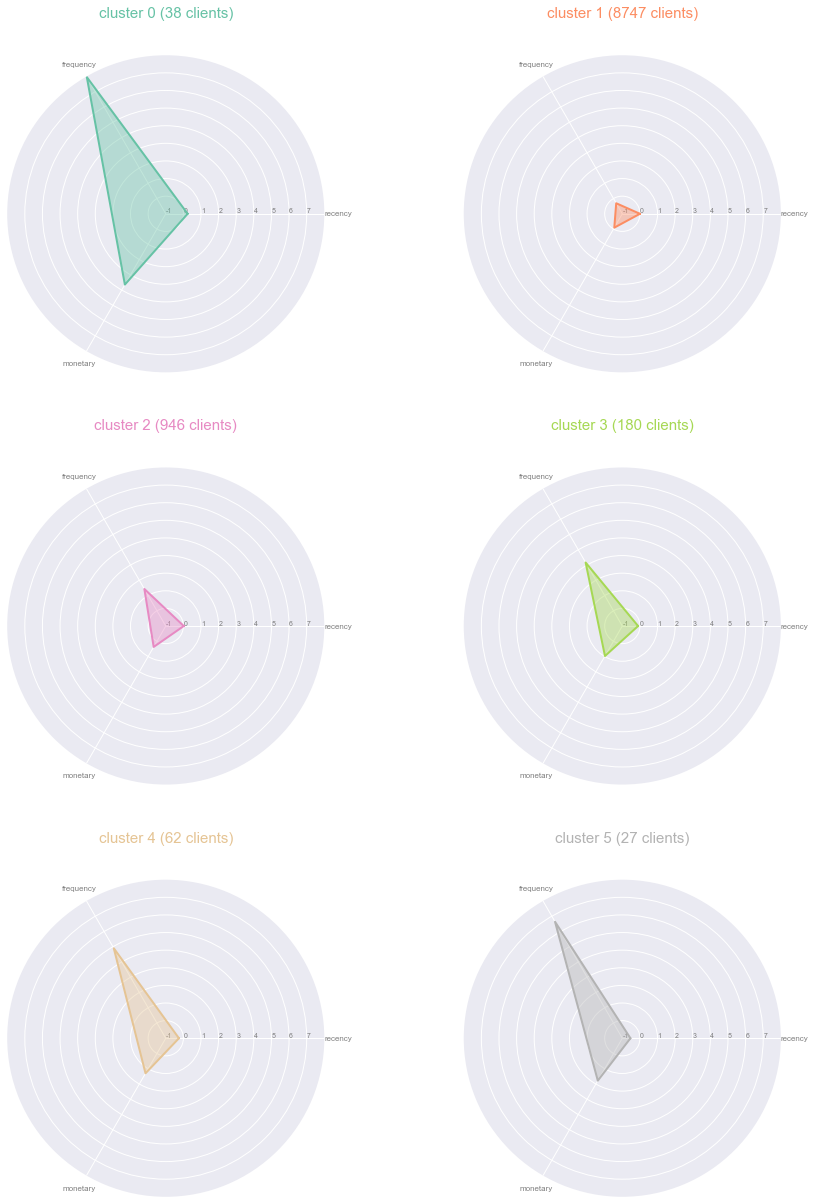

In [371]:

eps = 1.7
min_samples = 10

pipeline = define_pipeline(preprocessor, DBSCAN(**dbscan_parameters(eps,min_samples)))
pipeline.fit(ds_sample_rfm1)

#pipeline = dbscan_pipelines[min_samples][eps]

df_results = df_pipe_results(ds_sample_rfm1, pipeline)
radar_chart(df_results)


## 5 - Clustering RFM2 <a class="anchor" id="chapter5"></a>

In [372]:
ds_sample_rfm2 = rfm2.sample(sample_size)


### 5.1 - KMeans <a class="anchor" id="section_5_1"></a>

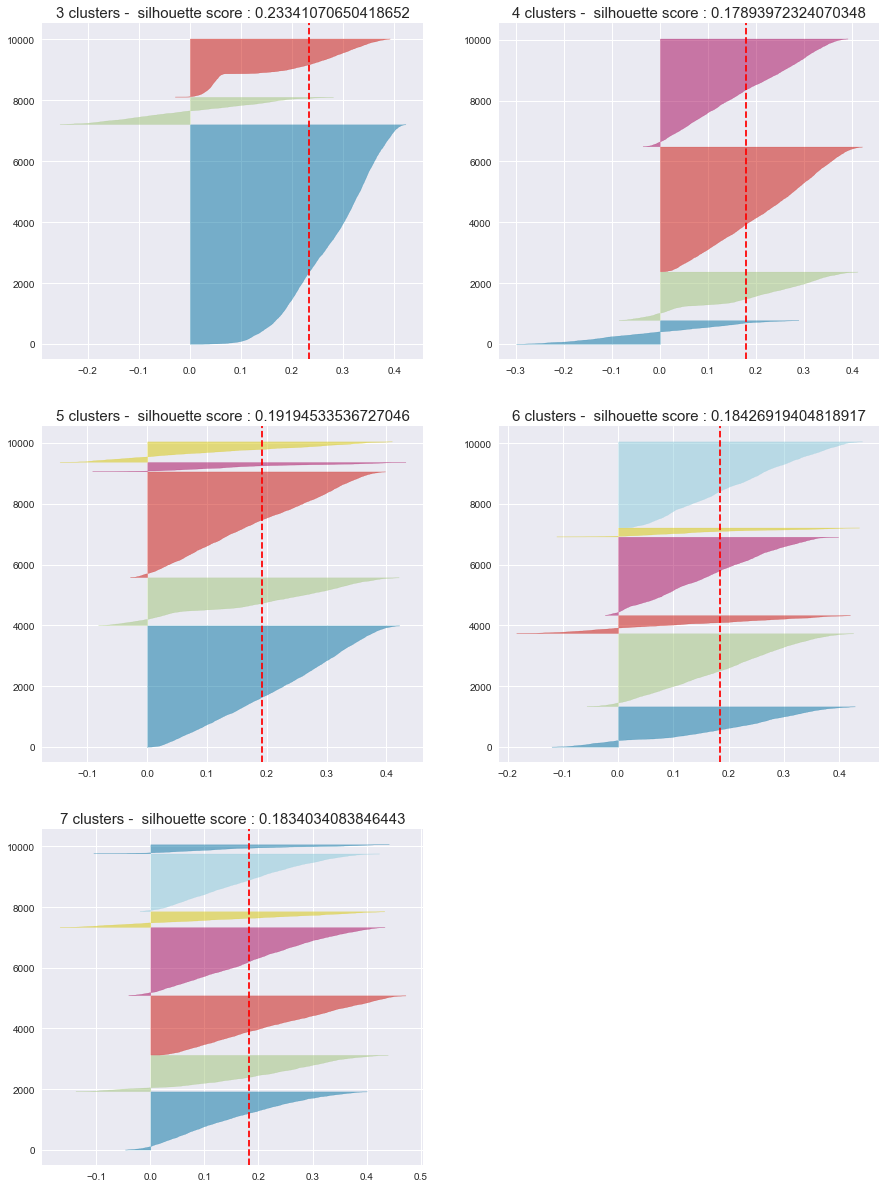

In [373]:
silhouette_scores,pipelines_rfm2_km = silhouette_analysis(ds_sample_rfm2)


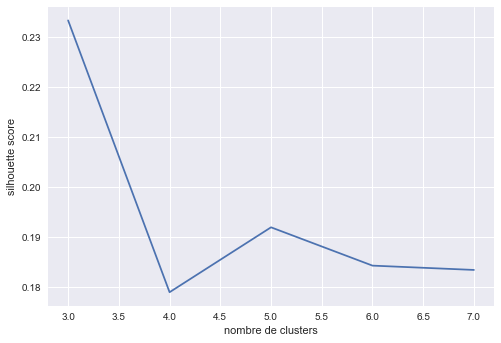

In [374]:
ax = sns.lineplot(data=silhouette_scores)
ax.set_xlabel('nombre de clusters')
ax.set_ylabel('silhouette score')
plt.show()

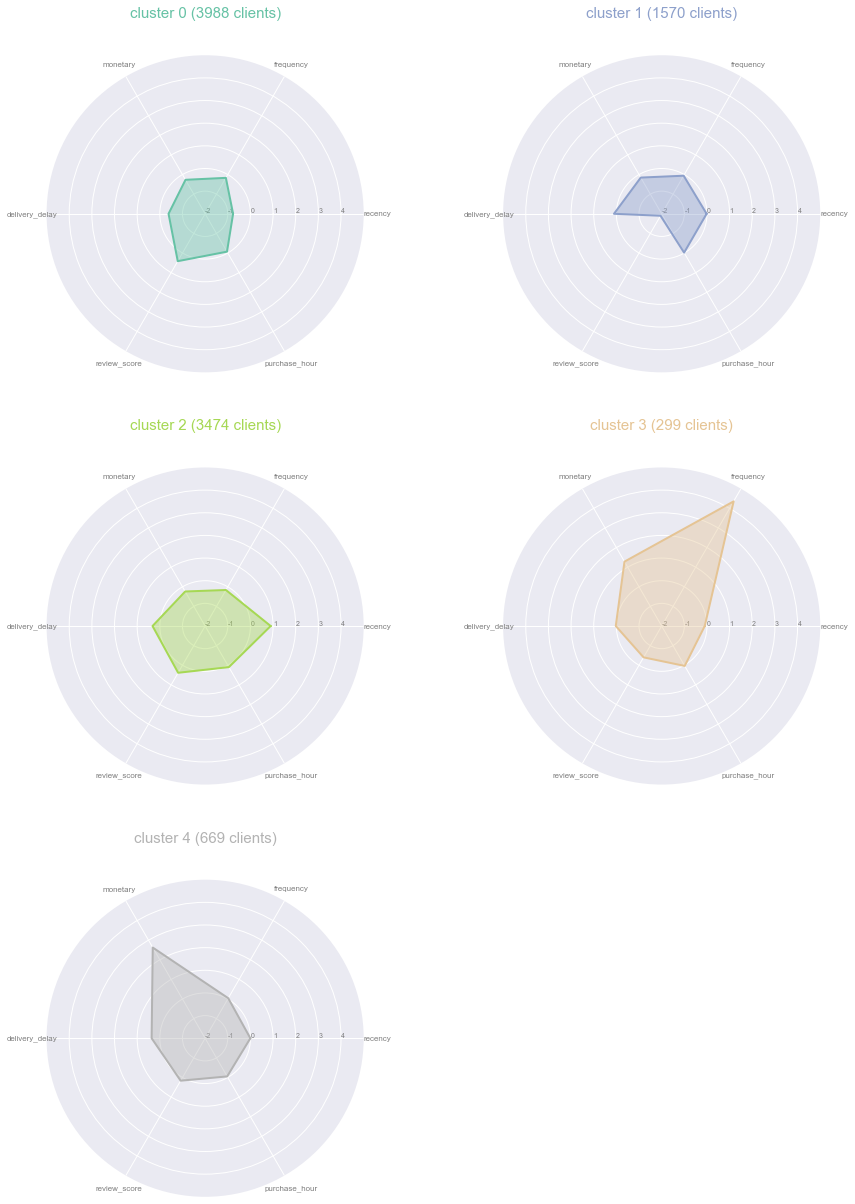

In [375]:
k = 5
pipeline = pipelines_rfm2_km[k]
df_results = df_pipe_results(ds_sample_rfm2, pipeline)
radar_chart(df_results)


### 5.2 - DBScan <a class="anchor" id="section_5_2"></a>

In [379]:
dbscan_silhouette_scores,dbscan_nb_clusters,dbscan_pipelines = dbscan_tuning(ds_sample_rfm2)


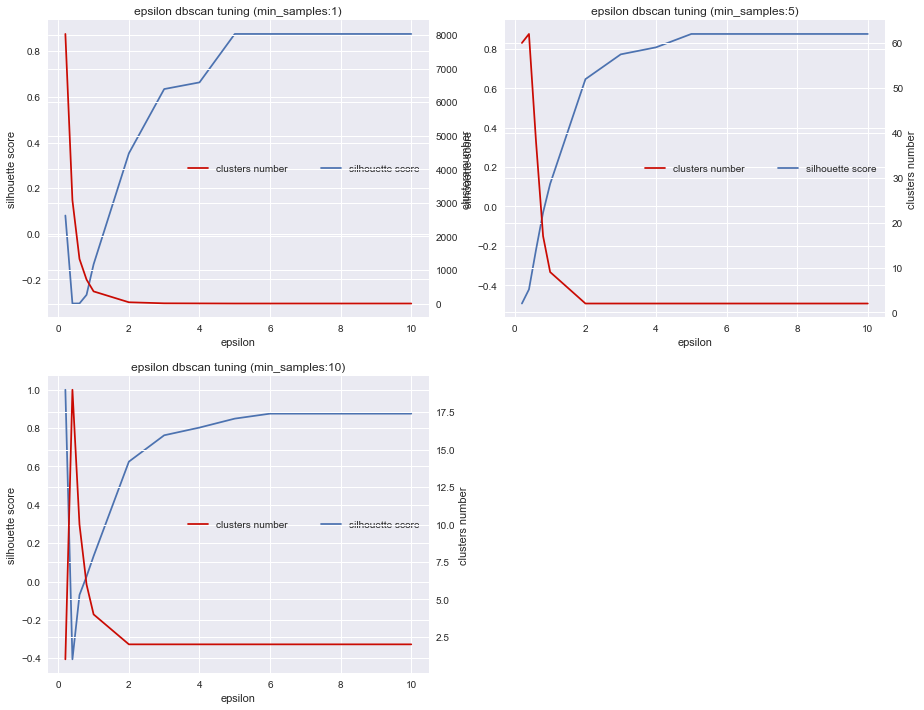

In [381]:
plot_dbscan_tuning(dbscan_silhouette_scores,dbscan_nb_clusters)


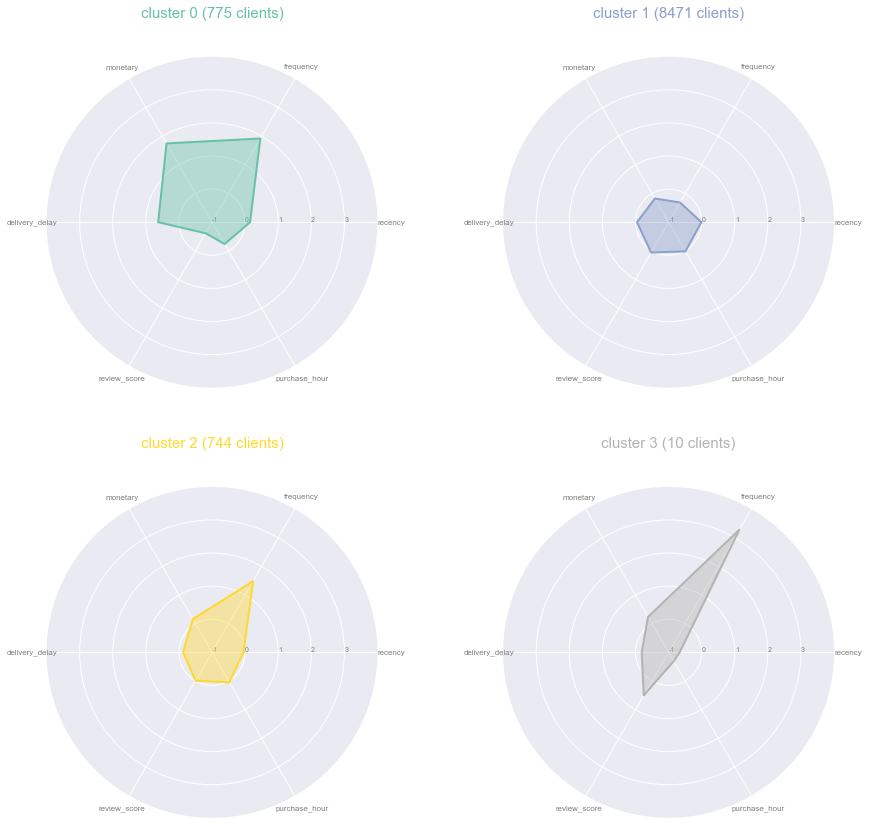

In [383]:
eps = 1
min_samples = 10

#pipeline = define_pipeline(preprocessor, DBSCAN(**dbscan_parameters(eps,min_samples)))
#pipeline.fit(ds_sample_rfm2)

pipeline = dbscan_pipelines[min_samples][eps]

df_results = df_pipe_results(ds_sample_rfm2, pipeline)
radar_chart(df_results)

## 6 - Visualisation TSNE <a class="anchor" id="chapter6"></a>

In [384]:
def tsne(df_results):
    """execute tsne on dataframe in parameter 

        Parameters:
        df_results (dataframe): the dataframe containing clustering results

        Returns:
        df_tsne: the dataframe tsne values

    """    
    tsne = TSNE(n_components=2, verbose=1, perplexity=30, n_iter=5000, learning_rate=200)
    df_features = df_results.drop(columns=['label'])
    tsne_results = tsne.fit_transform(df_features)
    df_tsne = pd.DataFrame(tsne_results, columns=['tsne1', 'tsne2'])
    df_tsne['label'] = df_results['label']
    return df_tsne


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.078s...
[t-SNE] Computed neighbors for 10000 samples in 0.240s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.047200
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.826424
[t-SNE] KL divergence after 5000 iterations: 0.668572


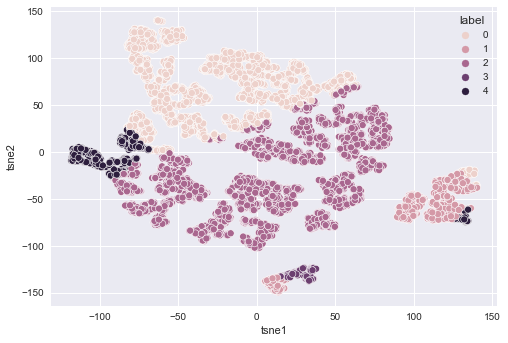

In [385]:

# model : StandardScaler / rfm1 / kmeans / n_clusters=5

k = 5

pipeline = define_pipeline(preprocessor, KMeans(**kmeans_parameters(k))) # define pipeline with model choosed
pipeline.fit(ds_sample_rfm1)
#pipeline = pipelines_rfm1_km[k]

df_results = df_pipe_results(ds_sample_rfm1, pipeline) 
df_tsne = tsne(df_results) # apply tsne on clustering results
sns.scatterplot(data=df_tsne, x="tsne1", y="tsne2", hue="label") # plot tsne results
plt.show()

## 7 - Maintenance <a class="anchor" id="chapter7"></a>

In [387]:
from dateutil.relativedelta import relativedelta

def add_months(date_ref, delay_number):
    """add months to a date 

        Parameters:
        date_ref : the date to add months
        delay_number : the number of months to add

        Returns:
        the new date with months added
    """    
    delay_date = date_ref + relativedelta(months=+delay_number)
    return delay_date


In [416]:
from datetime import datetime, timedelta
from sklearn.metrics.cluster import adjusted_rand_score

date_ref = datetime.strptime('2017-01-01', "%Y-%m-%d") # date of the initial model
date_end = datetime.strptime('2018-07-01', "%Y-%m-%d") # date until tests are done

ds_ref = create_rfm1(date_ref)

# some initializations 
k=5
months_number = 0
scores = []
current_date = date_ref

# fit reference model
scaler = StandardScaler()
ds_ref_preprocessed = scaler.fit_transform(ds_ref)
kmeans_ref = KMeans(**kmeans_parameters(k)).fit(ds_ref_preprocessed)

while current_date < date_end:
    
    ds_current = create_rfm1(current_date)
    
    scaler = StandardScaler()
    scaler.fit(ds_current)
    ds_current_preprocessed = scaler.transform(ds_current)
    
    # fit new model and for ref model, only predict
    kmeans_current = KMeans(**kmeans_parameters(k)).fit(ds_current_preprocessed)
    kmeans_ref_labels = kmeans_ref.predict(ds_current_preprocessed)
    
    score = adjusted_rand_score(kmeans_ref_labels, kmeans_current.labels_)
    scores.append([months_number,score])

    months_number += 3
    current_date = add_months(date_ref, months_number)

    

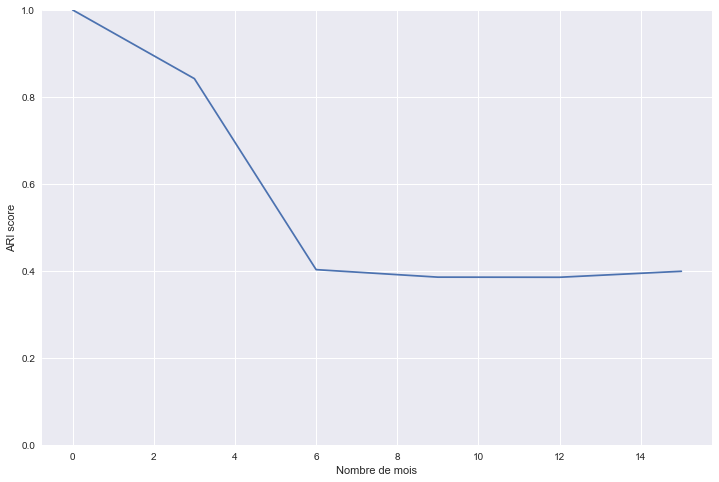

In [417]:
df_scores = pd.DataFrame(scores, columns=['Date', 'Score'])
plt.figure(figsize=(12,8))
ax = sns.lineplot(x = 'Date', y = 'Score', data = df_scores)
ax.set_xlabel("Nombre de mois")
ax.set_ylabel("ARI score")
ax.set_ylim([0, 1])

plt.show()

In [388]:

df_orders = pd.read_csv(data_path + "olist_orders_dataset.csv", low_memory=False)
df_customers = pd.read_csv(data_path + "olist_customers_dataset.csv", low_memory=False)
df_order_items = pd.read_csv(data_path + "olist_order_items_dataset.csv", low_memory=False)
df_order_payments = pd.read_csv(data_path + "olist_order_payments_dataset.csv", low_memory=False)

def create_rfm1(date_order):

    #date_param = datetime.strptime('2017-08-30', "%Y-%m-%d") 
    #df_orders = df_orders_copy.copy()

    df_orders_filtered = df_orders[pd.to_datetime(df_orders['order_purchase_timestamp']) < date_order]

    # group payments by order : aggregate sum payment_value
    df_order_payments_group = df_order_payments.groupby('order_id').agg({
        'payment_value': 'sum'
    })

    # group order_items(_extend) by order : aggregate number of products
    df_order_items_group = df_order_items.groupby('order_id').agg({
        'product_id': lambda x: len(x)
    })

    df_orders_extend = df_orders_filtered.merge(
        df_order_payments_group, on=['order_id']).merge(
        df_order_items_group, on=['order_id'])

    # group orders by year-month
    df_orders_extend = df_orders_extend[df_orders_extend['payment_value']<1000]
    df_orders_extend = df_orders_extend[df_orders_extend['order_status']=='delivered']

    df_customers_extend = df_customers.merge(
        df_orders_extend, on=['customer_id'])

    df_customers_extend['order_purchase_timestamp'] = pd.to_datetime(df_customers_extend['order_purchase_timestamp'])

    # calculate the last purchase date of the dataset
    last_date = df_customers_extend['order_purchase_timestamp'].max() + timedelta(days=1)

    rfm = df_customers_extend.groupby('customer_unique_id').agg({
        'order_purchase_timestamp': lambda x: (last_date - x.max()).days,
        'product_id': lambda x: sum(x),
        'payment_value': lambda x: sum(x)
    })

    rfm = rfm.rename(columns={
        'order_purchase_timestamp':'recency',
        'product_id':'frequency',
        'payment_value':'monetary'
    })
    
    return rfm


## 8 - Conclusion <a class="anchor" id="chapter8"></a>

Des clusters clients ont pu être définis grâce à des algorithmes de machine learning.  
Ces groupes de clients permettent de lancer des actions de communication ciblées.  
L'algorithme KMeans a donné de bons résultats.  
Il va falloir prévoir une mise à jour du modèle tous les 3 mois environ.  